# Indian Food Truck Market Analysis in Bangalore

## Notebook Goal

This notebook analyzes restaurant data from Zomato to evaluate market conditions and identify opportunities for launching an Indian food truck in Bangalore.

## Main Objectives
- Load and inspect the Zomato dataset
- Identify relevant restaurant and customer information
- Clean and prepare the dataset for analysis
- Analyze patterns related to competition, pricing, and customer ratings
- Identify potential market opportunities

## 1. Project Setup

### Project Context

This project aims to evaluate the feasibility of launching an Indian food truck in Bangalore using a data-driven market research approach.

The analysis is structured into two complementary components:

- **Market & Demand Analysis (API-based)**  
  Focused on identifying high-traffic areas such as metro stations and tech parks using external APIs.

- **Restaurant & Competition Analysis (this notebook)**  
  Focused on analyzing existing restaurant data from Zomato, including competition levels, customer ratings, pricing patterns, and market positioning.

This notebook specifically contributes to understanding the competitive landscape and customer behavior in the Bangalore restaurant market.

---

### Role of This Notebook

This notebook focuses on analyzing the restaurant ecosystem in Bangalore using Zomato data.

The objective is to understand how the market behaves by evaluating:

- competition density (number of restaurants per area)  
- customer satisfaction (ratings and reviews)  
- pricing patterns  
- distribution of restaurant types and cuisines  

This analysis helps identify patterns, saturation levels, and potential gaps where a food truck could be strategically positioned.

---

### Key Analytical Questions

- Which areas in Bangalore have the highest concentration of restaurants?  
- How strong is the competition in different areas?  
- What are the average ratings and customer satisfaction levels?  
- How does pricing vary across locations?  
- Are there areas with high activity but potential gaps in affordable or quick-service options?
- Best place to locate our Food truck according to our Dataset and API

---

### Data Source

The primary dataset used in this notebook is the Zomato dataset, which includes:

- restaurant name and location  
- cuisine types  
- average cost for two people  
- ratings and number of votes  
- restaurant category (e.g., quick bites, casual dining)

This dataset enables both quantitative analysis (counts, averages, distributions) and market pattern identification.

---

### Analytical Objective

The goal of this notebook is to extract insights about:

- competition density across different areas  
- customer perception through ratings  
- pricing distribution and affordability  
- potential market gaps  

These insights will contribute to identifying the most promising areas to launch an Indian food truck, especially when combined with high-traffic location data from external APIs.

## 2. Import Libraries

In [1]:
# Import core libraries for data analysis
import pandas as pd
import numpy as np

# improve display in notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 3. Load Dataset

In [2]:
# Load dataset from current folder
df = pd.read_csv("zomato.csv")

# Preview first rows
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
# Check dataset shape (rows, columns)
print("Dataset shape:", df.shape)

Dataset shape: (51717, 17)


## 4. Initial Data Inspection

In [4]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [5]:
# Check for missing values
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [6]:
# Summary statistics for numerical columns
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [7]:
# Preview column names
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [8]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

### Observations

- The dataset contains 51,717 entries and 17 columns.

- Most columns are categorical (object type), while only "votes" is numerical at this stage.

- The "rate" column is currently stored as a string (e.g., "4.1/5"), which will require cleaning before analysis.

- Missing values are present in several key columns:
  - "rate" has 7,775 missing values
  - "dish_liked" has a significant number of missing values (28,078)
  - "rest_type" and "cuisines" also contain some missing data

- No duplicate rows were found in the dataset.

- The "votes" column shows a wide distribution, with a maximum value of 16,832, indicating the presence of highly popular restaurants.

### Key Data Challenges

- The "rate" column needs to be converted to a numerical format.
- High missing values in "dish_liked" may limit its usefulness.
- Some categorical columns may require standardization or grouping.

## 5. Data Cleaning 

In [9]:
# Function to simplify cuisine categories
def categorize_cuisine(cuisine):
    if pd.isna(cuisine):
        return "Unknown"

    cuisine = cuisine.lower()

    if "indian" in cuisine:
        return "Indian"
    elif "chinese" in cuisine:
        return "Chinese"
    elif "italian" in cuisine:
        return "Italian"
    elif "cafe" in cuisine or "coffee" in cuisine:
        return "Cafe"
    elif "fast food" in cuisine or "burger" in cuisine:
        return "Fast Food"
    else:
        return "Other"

In [10]:
# Apply categorization
df["main_cuisine"] = df["cuisines"].apply(categorize_cuisine)

# Verify new categories
df["main_cuisine"].value_counts()

main_cuisine
Indian       25161
Other        12419
Fast Food     4762
Chinese       3544
Cafe          3443
Italian       2343
Unknown         45
Name: count, dtype: int64

In [11]:
# Clean the 'rate' column by removing '/5' and handling invalid values
def clean_rate(rate):
    if pd.isna(rate):
        return None

    rate = str(rate).strip()

    if rate in ["NEW", "-", ""]:
        return None

    return float(rate.split('/')[0])

In [12]:
# Apply cleaning
df["rate"] = df["rate"].apply(clean_rate)

In [13]:
# Validate result
print("Data type:", df["rate"].dtype)
print("Missing values:", df["rate"].isnull().sum())

Data type: float64
Missing values: 10052


In [14]:
# Clean 'approx_cost(for two people)' column
def clean_cost(cost):
    if pd.isna(cost):
        return None

    cost = str(cost).replace(",", "").strip()

    if cost == "":
        return None

    return float(cost)

In [15]:
# Apply cleaning
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].apply(clean_cost)

In [16]:
# Preview
df["approx_cost(for two people)"].head()

0    800.0
1    800.0
2    800.0
3    300.0
4    600.0
Name: approx_cost(for two people), dtype: float64

### Cleaning Summary

The dataset has been standardized to make it suitable for analysis.

The following transformations were applied:
- cuisine values were grouped into broader categories
- rating values were converted from strings to numeric format
- cost values were cleaned and converted to numeric format

The next step is to narrow the dataset to the most relevant features and restaurants for the business objective.

## 6. Filter Relevant Data

### Selected Relevant Features

Based on the project objectives, the following columns were selected for analysis:

- **name** → restaurant identification
- **location** → neighborhood-level analysis
- **cuisines** → identify Indian restaurants
- **rate** → customer satisfaction
- **votes** → popularity indicator
- **approx_cost(for two people)** → pricing benchmark
- **rest_type** → restaurant category (casual dining, quick bites, etc.)

In [17]:
# Select relevant columns for analysis
selected_columns = [
    "name",
    "location",
    "cuisines",
    "main_cuisine",
    "rate",
    "votes",
    "approx_cost(for two people)",
    "rest_type"
]

df_selected = df[selected_columns].copy()

# Preview selected dataset
df_selected

,name,location,cuisines,main_cuisine,rate,votes,approx_cost(for two people),rest_type
0,Jalsa,Banashankari,"North Indian, Mughlai, Chinese",Indian,4.1,775,800.0,Casual Dining
1,Spice Elephant,Banashankari,"Chinese, North Indian, Thai",Indian,4.1,787,800.0,Casual Dining
2,San Churro Cafe,Banashankari,"Cafe, Mexican, Italian",Italian,3.8,918,800.0,"Cafe, Casual Dining"
3,Addhuri Udupi Bhojana,Banashankari,"South Indian, North Indian",Indian,3.7,88,300.0,Quick Bites
4,Grand Village,Basavanagudi,"North Indian, Rajasthani",Indian,3.8,166,600.0,Casual Dining
...,...,...,...,...,...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,Whitefield,Continental,Other,3.6,27,1500.0,Bar
51713,Vinod Bar And Restaurant,Whitefield,Finger Food,Other,NaN,0,600.0,Bar
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,Whitefield,Finger Food,Other,NaN,0,2000.0,Bar
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,"ITPL Main Road, Whitefield",Finger Food,Other,4.3,236,2500.0,Bar


The dataset now contains 51,717 rows and 8 relevant columns.

This confirms that no rows were removed at this stage, only irrelevant features were excluded to focus the analysis on key business variables.

### Secondary Columns

- **dish_liked** → qualitative insights (limited due to missing values)
- **reviews_list** → potential for text analysis (if time allows)

### Columns excluded

- **url, address, phone** → not relevant for analysis
- **menu_item** → too sparse / not useful for current scope

In [18]:
# Filter only Indian restaurants
df_indian = df_selected[df_selected["main_cuisine"] == "Indian"].copy()

# Preview result
print("Indian restaurants dataset shape:", df_indian.shape)
df_indian.head()

Indian restaurants dataset shape: (25161, 8)


,name,location,cuisines,main_cuisine,rate,votes,approx_cost(for two people),rest_type
0,Jalsa,Banashankari,"North Indian, Mughlai, Chinese",Indian,4.1,775,800.0,Casual Dining
1,Spice Elephant,Banashankari,"Chinese, North Indian, Thai",Indian,4.1,787,800.0,Casual Dining
3,Addhuri Udupi Bhojana,Banashankari,"South Indian, North Indian",Indian,3.7,88,300.0,Quick Bites
4,Grand Village,Basavanagudi,"North Indian, Rajasthani",Indian,3.8,166,600.0,Casual Dining
5,Timepass Dinner,Basavanagudi,North Indian,Indian,3.8,286,600.0,Casual Dining


In [19]:
# Keep only the most relevant columns for analysis
columns_to_keep = [
    "name",
    "location",
    "main_cuisine",
    "rate",
    "votes",
    "approx_cost(for two people)",
    "rest_type"
]
# Create analysis dataset with only relevant columns (excluding non-useful fields like url, address, phone)
df_indian = df_indian[columns_to_keep].copy()

# Final preview
df_indian.head()

,name,location,main_cuisine,rate,votes,approx_cost(for two people),rest_type
0,Jalsa,Banashankari,Indian,4.1,775,800.0,Casual Dining
1,Spice Elephant,Banashankari,Indian,4.1,787,800.0,Casual Dining
3,Addhuri Udupi Bhojana,Banashankari,Indian,3.7,88,300.0,Quick Bites
4,Grand Village,Basavanagudi,Indian,3.8,166,600.0,Casual Dining
5,Timepass Dinner,Basavanagudi,Indian,3.8,286,600.0,Casual Dining


In [20]:
# Check missing values in the filtered dataset
df_indian.isnull().sum()

name                              0
location                          0
main_cuisine                      0
rate                           4901
votes                             0
approx_cost(for two people)     144
rest_type                       124
dtype: int64

In [21]:
# Remove rows with missing values in key analytical variables
df_indian = df_indian[
    df_indian["rate"].notna() &
    df_indian["approx_cost(for two people)"].notna()
].copy()

# Check final shape
print("Cleaned Indian dataset shape:", df_indian.shape)

Cleaned Indian dataset shape: (20150, 7)


In [22]:
#filter by rest_type: Quick Bites
df_indian["rest_type"].value_counts()

rest_type
Quick Bites                    8264
Casual Dining                  6663
Delivery                        940
Casual Dining, Bar              705
Takeaway, Delivery              648
Bar                             429
Cafe                            226
Bar, Casual Dining              217
Pub                             215
Food Court                      191
Fine Dining                     185
Lounge                          178
Pub, Casual Dining              151
Mess                            125
Microbrewery, Casual Dining      93
Casual Dining, Cafe              84
Sweet Shop, Quick Bites          58
Casual Dining, Pub               56
Casual Dining, Microbrewery      47
Pub, Cafe                        40
Pub, Microbrewery                38
Microbrewery, Pub                37
Lounge, Casual Dining            30
Cafe, Quick Bites                29
Kiosk                            28
Cafe, Casual Dining              27
Fine Dining, Bar                 23
Quick Bites, Desse

In [23]:
df_quick_bites = df_indian[
    df_indian["rest_type"].str.contains("Quick Bites", na=False)
].copy()

df_quick_bites.head()

,name,location,main_cuisine,rate,votes,approx_cost(for two people),rest_type
3,Addhuri Udupi Bhojana,Banashankari,Indian,3.7,88,300.0,Quick Bites
26,Coffee Tindi,Banashankari,Indian,3.8,75,200.0,"Cafe, Quick Bites"
31,Foodiction,Banashankari,Indian,2.8,506,500.0,Quick Bites
34,Faasos,Banashankari,Indian,4.2,415,500.0,Quick Bites
36,Fast And Fresh,Banashankari,Indian,2.8,91,400.0,Quick Bites


In [24]:
print("Quick Bites dataset shape:", df_quick_bites.shape) #Validate new shape dataset

Quick Bites dataset shape: (8431, 7)


In [25]:
df_quick_bites["rest_type"].value_counts() #confirme the filter is giving us a good data

rest_type
Quick Bites                    8264
Sweet Shop, Quick Bites          58
Cafe, Quick Bites                29
Quick Bites, Dessert Parlor      22
Quick Bites, Sweet Shop          17
Quick Bites, Bakery              13
Food Court, Quick Bites          10
Beverage Shop, Quick Bites        6
Casual Dining, Quick Bites        4
Quick Bites, Mess                 4
Quick Bites, Beverage Shop        3
Quick Bites, Cafe                 1
Name: count, dtype: int64

### Filtering for Quick Bites (Food Truck Proxy)

To better align the analysis with the food truck business model, we filter the dataset to include only "Quick Bites" type restaurants.

This category represents fast, casual dining options that are more comparable to food truck operations in terms of pricing, service speed, and customer behavior. 

A significant portion of Indian restaurants in Bangalore fall under the "Quick Bites" category, reinforcing that fast and casual dining is a dominant and relevant segment for a food truck business model.

In [26]:
df_quick_bites["location"].value_counts()

location
BTM                              1277
HSR                               409
Marathahalli                      387
Jayanagar                         350
Whitefield                        342
Bannerghatta Road                 294
JP Nagar                          279
Bellandur                         239
Electronic City                   233
Koramangala 1st Block             233
Banashankari                      217
Koramangala 6th Block             214
Ulsoor                            210
Indiranagar                       190
Basavanagudi                      183
Sarjapur Road                     180
Brookefield                       148
Koramangala 5th Block             147
Rajajinagar                       145
Frazer Town                       141
Shivajinagar                      138
Brigade Road                      131
Malleshwaram                      129
Richmond Road                     126
Ejipura                           126
Banaswadi                         112
New

In [27]:
df_quick_bites.groupby("location")["rate"].mean() # undertanding Customer satisfaction

location
BTM                              3.514565
Banashankari                     3.595853
Banaswadi                        3.444643
Bannerghatta Road                3.446259
Basavanagudi                     3.660656
Basaveshwara Nagar               3.603571
Bellandur                        3.410879
Bommanahalli                     3.161765
Brigade Road                     3.477863
Brookefield                      3.561486
CV Raman Nagar                   3.410000
Church Street                    3.593333
City Market                      3.700000
Commercial Street                3.357143
Cunningham Road                  3.587879
Domlur                           3.483871
Ejipura                          3.403175
Electronic City                  3.447639
Frazer Town                      3.526241
HBR Layout                       3.511538
HSR                              3.606601
Hennur                           3.332500
Hosur Road                       4.085714
ITPL Main Road, Whitefiel

In [28]:
df_quick_bites.groupby("location")["approx_cost(for two people)"].mean() #undestending pricing

location
BTM                              338.034456
Banashankari                     269.815668
Banaswadi                        305.357143
Bannerghatta Road                347.278912
Basavanagudi                     222.950820
Basaveshwara Nagar               301.785714
Bellandur                        375.941423
Bommanahalli                     363.970588
Brigade Road                     294.274809
Brookefield                      325.337838
CV Raman Nagar                   267.500000
Church Street                    323.333333
City Market                      250.000000
Commercial Street                221.428571
Cunningham Road                  293.939394
Domlur                           276.290323
Ejipura                          300.000000
Electronic City                  342.489270
Frazer Town                      322.340426
HBR Layout                       330.769231
HSR                              329.462103
Hennur                           348.750000
Hosur Road             

In [29]:
df_quick_bites.groupby("location")["votes"].mean() # demand

location
BTM                               97.819107
Banashankari                     102.354839
Banaswadi                         44.642857
Bannerghatta Road                 77.091837
Basavanagudi                     206.852459
Basaveshwara Nagar                76.285714
Bellandur                         82.493724
Bommanahalli                      52.838235
Brigade Road                      39.954198
Brookefield                      114.472973
CV Raman Nagar                    51.650000
Church Street                    272.700000
City Market                       58.045455
Commercial Street                 22.428571
Cunningham Road                   33.636364
Domlur                            91.080645
Ejipura                           67.396825
Electronic City                   87.562232
Frazer Town                       79.134752
HBR Layout                        13.961538
HSR                              138.826406
Hennur                            27.200000
Hosur Road             

In [30]:
# Comparative table by location

# Group restaurants by location and calculate:
# - average votes as demand proxy
# - average cost as pricing proxy

comparison = df_quick_bites.groupby('location').agg({
    'votes':'mean',
    'approx_cost(for two people)':'mean'
})

comparison['competition'] = df_quick_bites.groupby('location').size()

# Opportunity Score formula:
# Higher votes = higher demand
# Lower competition = better opportunity
# Lower costs = stronger fit for affordable food truck model

comparison['opportunity_score'] = (
    comparison['votes'] /
    (comparison['competition'] * comparison['approx_cost(for two people)'])
)

# Rank locations from highest opportunity to lowest

comparison.sort_values(
    by='opportunity_score',
    ascending=False
)

,votes,approx_cost(for two people),competition,opportunity_score
location,,,,
Race Course Road,485.000000,400.000000,1,1.212500
Lavelle Road,869.400000,400.000000,10,0.217350
Hosur Road,477.000000,271.428571,14,0.125526
Seshadripuram,69.750000,250.000000,4,0.069750
"Varthur Main Road, Whitefield",100.375000,250.000000,8,0.050188
Nagarbhavi,10.000000,250.000000,1,0.040000
Yelahanka,44.000000,325.000000,4,0.033846
Kanakapura Road,35.750000,300.000000,4,0.029792
Church Street,272.700000,323.333333,30,0.028113


We created a custom opportunity index to estimate favorable locations by combining demand (votes), competition (number of quick bites), and pricing levels

In [31]:
# Common locations we found between dataset and API

common_locations = [
'HSR',
'Whitefield',
'Jayanagar',
'JP Nagar',
'Basavanagudi',
'Majestic'
]


# Filter only selected locations

df_selected = df_quick_bites[
    df_quick_bites['location'].isin(common_locations)
]


# Compare table per location

comparison = df_selected.groupby('location').agg({
    'votes':'mean',
    'approx_cost(for two people)':'mean'
})


# Competition

comparison['competition'] = df_selected.groupby('location').size()


# Opportunity Score

comparison['opportunity_score'] = (
    comparison['votes'] /
    (comparison['competition'] * comparison['approx_cost(for two people)'])
)


# Rank opportunities

comparison.sort_values(
    by='opportunity_score',
    ascending=False
)

,votes,approx_cost(for two people),competition,opportunity_score
location,,,,
Basavanagudi,206.852459,222.950820,183,0.005070
Majestic,26.750000,264.062500,32,0.003166
Jayanagar,152.351429,303.000000,350,0.001437
HSR,138.826406,329.462103,409,0.001030
JP Nagar,87.559140,313.799283,279,0.001000
Whitefield,68.687135,356.432749,342,0.000563


### Preliminary Findings from Opportunity Score Analysis

We created a custom Food Truck Opportunity Index based on:

*Opportunity= Average Votes/ Competition×Average Cost*

#### Where:

Average Votes = proxy for customer demand
Competition = number of Quick Bites in each location
Average Cost = proxy for pricing intensity

#### The model suggests that:

- Basavanagudi shows the highest opportunity score, indicating a strong balance between demand, moderate competition, and lower pricing.
- Majestic also ranks high, although results may be influenced by very low competition levels, which could artificially inflate the score.
- Whitefield, HSR and Jayanagar, despite having high activity, show lower opportunity scores due to higher competition and pricing, suggesting possible market saturation.

#### Important Limitation

This model may favor areas with very low competition, which can distort results.

Further validation is needed by incorporating:

- Foot traffic data from metro stations
- Tech park mobility data
- Additional demand indicators

#### Strategic Interpretation

Results suggest two possible food truck positioning strategies:

1. Enter established high-demand markets (HSR, Whitefield)
2. Target lower-competition opportunity gaps (Basavanagudi, possibly Majestic)

## 7. Exploratory Data Analysis

In [32]:
df_quick_bites.head(10) # Quick overview of the cleaned dataset

,name,location,main_cuisine,rate,votes,approx_cost(for two people),rest_type
3,Addhuri Udupi Bhojana,Banashankari,Indian,3.7,88,300.0,Quick Bites
26,Coffee Tindi,Banashankari,Indian,3.8,75,200.0,"Cafe, Quick Bites"
31,Foodiction,Banashankari,Indian,2.8,506,500.0,Quick Bites
34,Faasos,Banashankari,Indian,4.2,415,500.0,Quick Bites
36,Fast And Fresh,Banashankari,Indian,2.8,91,400.0,Quick Bites
39,Maruthi Davangere Benne Dosa,Banashankari,Indian,4.0,17,150.0,Quick Bites
46,Kitchen Garden,Kumaraswamy Layout,Indian,3.6,244,300.0,Quick Bites
49,Tasty Bytes,Kumaraswamy Layout,Indian,3.1,245,300.0,Quick Bites
50,Petoo,Banashankari,Indian,3.7,21,450.0,Quick Bites
65,Kabab Magic,Basavanagudi,Indian,4.1,1720,400.0,Quick Bites


In [33]:
df_quick_bites.describe() #Quick bite restaurants concentration

,rate,votes,approx_cost(for two people)
count,8431.000000,8431.000000,8431.000000
mean,3.528668,104.846044,323.349543
std,0.357983,245.212435,112.151825
min,2.100000,0.000000,40.000000
25%,3.300000,13.000000,250.000000
50%,3.600000,35.000000,300.000000
75%,3.800000,99.000000,400.000000
max,4.800000,4460.000000,800.000000


In [34]:
df_quick_bites.shape

(8431, 7)

### 1. Which areas have highest concentration?

In [35]:
df_quick_bites['location'].value_counts().head(10) #bar chart

location
BTM                      1277
HSR                       409
Marathahalli              387
Jayanagar                 350
Whitefield                342
Bannerghatta Road         294
JP Nagar                  279
Bellandur                 239
Electronic City           233
Koramangala 1st Block     233
Name: count, dtype: int64

### Summary statistics

In [36]:
df_quick_bites[['rate','votes','approx_cost(for two people)']].describe()

,rate,votes,approx_cost(for two people)
count,8431.000000,8431.000000,8431.000000
mean,3.528668,104.846044,323.349543
std,0.357983,245.212435,112.151825
min,2.100000,0.000000,40.000000
25%,3.300000,13.000000,250.000000
50%,3.600000,35.000000,300.000000
75%,3.800000,99.000000,400.000000
max,4.800000,4460.000000,800.000000


In [37]:
#!pip install seaborn

In [38]:
import seaborn as sns
import matplotlib as plt

<Axes: ylabel='location'>

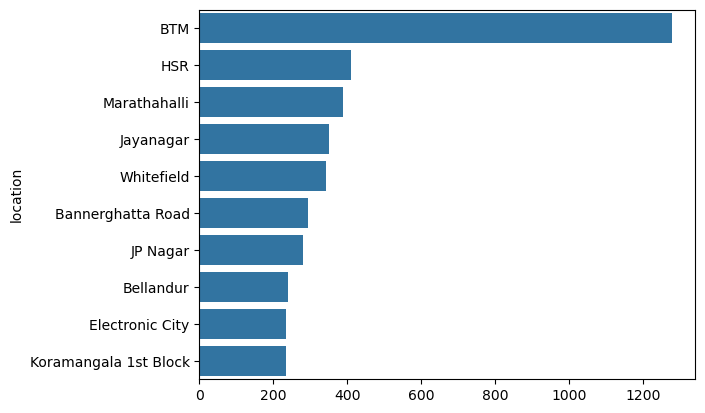

In [39]:
# Restaurant concentration to answer: Which areas have the highest concentration of restaurants?
top10 = df_quick_bites['location'].value_counts().head(10)

sns.barplot(
x=top10.values,
y=top10.index
)

Restaurant activity is highly concentrated in a small number of areas, particularly BTM, HSR, Jayanagar and Whitefield. These locations appear to be major Quick Bites clusters and may represent strong demand, but also potentially higher competitive pressure for a new food truck entrant.

<Axes: xlabel='rate', ylabel='Count'>

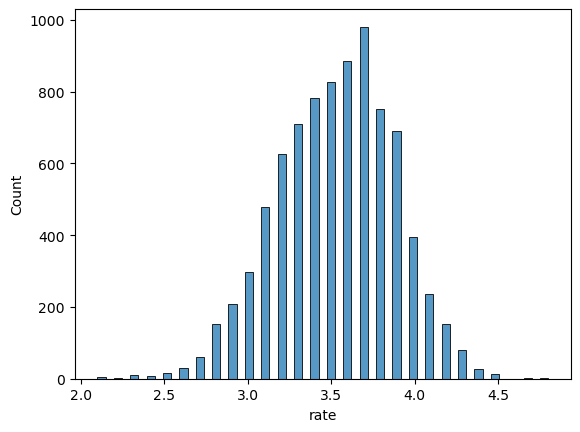

In [40]:
# Ratings histogram
sns.histplot(df_quick_bites['rate'])

Ratings cluster between 3.3 and 3.8, suggesting relatively stable customer satisfaction across the Quick Bites segment. There is limited variability and no major outliers, which may indicate that quality expectations are relatively consistent across locations.

<Axes: xlabel='votes', ylabel='Count'>

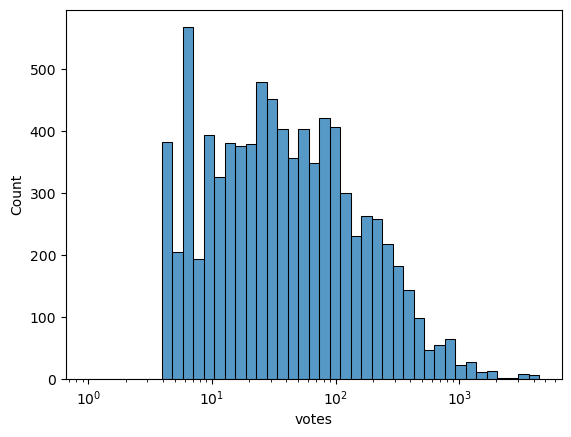

In [41]:
#Votes histogram 
sns.histplot(df_quick_bites['votes'], log_scale=True)

Customer engagement is highly right-skewed: most restaurants receive relatively low review activity, while a small number of highly popular restaurants capture disproportionately large numbers of votes. This suggests demand may be concentrated¨¨ among a limited set of strong performers.

<Axes: xlabel='approx_cost(for two people)', ylabel='Count'>

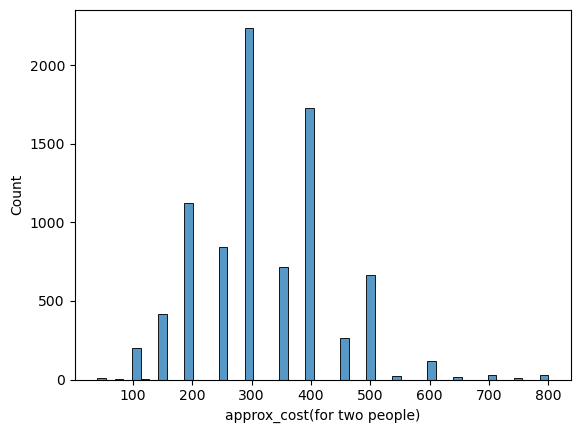

In [42]:
# Cost histogram
sns.histplot(df_quick_bites['approx_cost(for two people)'])

Pricing appears concentrated around 300–400 ropees for two people, suggesting a common market pricing benchmark in the Quick Bites segment. This may help define a potential pricing range for a food truck concept targeting affordability.

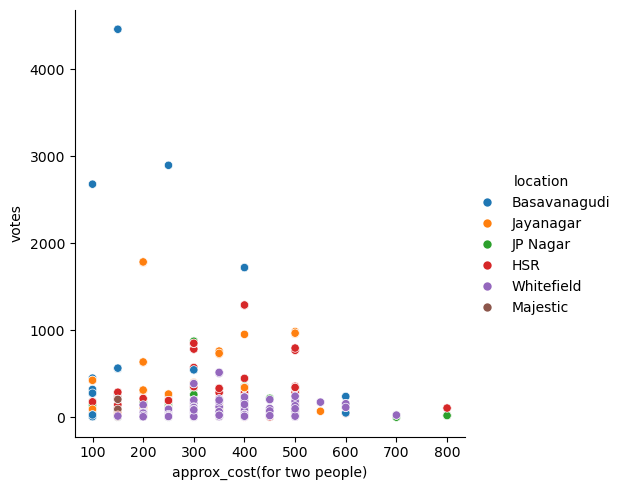

In [43]:
#votes vs cost by location
sns.relplot(
    data=df_selected,
    x='approx_cost(for two people)',
    y='votes',
    hue='location'
)

The relationship between pricing and customer engagement does not appear strictly linear, suggesting higher prices do not necessarily lead to higher popularity. Some locations show restaurants with strong vote counts at moderate price points, which may indicate potential opportunity for affordable, high-demand positioning.

In [44]:
comparison[['opportunity_score']].sort_values(
    by='opportunity_score',
    ascending=False
)

,opportunity_score
location,
Basavanagudi,0.005070
Majestic,0.003166
Jayanagar,0.001437
HSR,0.001030
JP Nagar,0.001000
Whitefield,0.000563


*Interpretation*

The opportunity index suggests that Basavanagudi and Majestic may offer favorable conditions due to a stronger balance between demand, competition and pricing.

*Limitation*

Results should be interpreted cautiously, as locations with very low competition may artificially inflate scores and require further validation using API mobility data.

# Project Phase: Market Demand Mapping (TomTom API)
## Objective
The primary goal of this notebook section is to identify High-Traffic Demand Hubs across Bangalore. We are specifically looking for locations where large numbers of potential customers gather during peak meal times:

Tech Parks: To capture the 1:00 PM - 2:00 PM office lunch crowd.

Metro Stations: To capture the "Grab-and-Go" morning and evening commuter crowd.

## Methodology
We use the TomTom POI (Point of Interest) Search API to programmatically fetch geographic data that isn't available in our static Zomato dataset.

Query Strategy: Searching for keywords "Tech Park" and "Metro Station" within a 20km radius of the city center.

Data Enrichment: Extracting postalCode and municipalitySubdivision (Neighborhood) to create a common link with the Zomato "Supply" dataset.

## Expected Outcome
By the end of this script, we will have two structured DataFrames (tech_df and metro_df). These will be used to calculate the Opportunity Score by comparing these "Demand Points" against the "Restaurant Supply" from Zomato.

In [45]:
import requests
import pandas as pd

## 1. TOMTOM API CONFIGURATION

In [46]:
API_KEY = "WxH16MZLVvQztZTNWnR7hPglcqjvet8c" 

### Searches for Points of Interest (POIs) in Bangalore using TomTom API.
### Used to identify high-traffic areas like Tech Parks and Metro Stations

### **Data Dictionary: TomTom API Output**

| Column Name | Data Type | Description | Example Value |
| :--- | :--- | :--- | :--- |
| **Name** | String | The official name of the Point of Interest (POI). | "Manyata Tech Park" |
| **Address** | String | The full, formatted physical address. | "Nagawara, Bangalore 560045" |
| **Lat** | Float | The precise North/South geographic coordinate. | 12.9716 |
| **Lon** | Float | The precise East/West geographic coordinate. | 77.5946 |
| **Dist_Meters** | Float | Straight-line distance from the search center in meters. | 8450.5 |
| **postalCode** | String | The 6-digit Bangalore postal code (PIN code). | "560045" |
| **neighborhood** | String | The specific local area or sub-locality name. | "Nagawara" |

In [47]:
def search_bangalore_pois(query_text):
    # This URL searches for specific keywords near a location
    url = f"https://api.tomtom.com/search/2/poiSearch/{query_text}.json"
    
    params = {
        'key': API_KEY,
        'lat': 12.9716,      # Bangalore Latitude
        'lon': 77.5946,      # Bangalore Longitude
        'radius': 20000,     # 20km radius (covers almost all of Bangalore)
        'limit': 50,         # Start with 50 results to be safe
        'countrySet': 'IN'   # Limits search to India
    }
    
    try:
        response = requests.get(url, params=params)
        
        # Check if the key is working
        if response.status_code == 403:
            return "Error: Your API Key is invalid or not yet active. Wait 10 mins after creating it."
        
        data = response.json()
        results = data.get('results', [])
        
        if not results:
            return "No results found. Try broadening your query text."

        # Extracting into a clean list
        output = []
        for r in results:
            output.append({
                'Name': r['poi'].get('name'),
                'Address': r['address'].get('freeformAddress'),
                'Dist_Meters': r.get('dist'),
                'postalCode': r['address'].get('postalCode'),
                'neighborhood': r['address'].get('municipalitySubdivision'),
                'lat': r['position'].get('lat'),
                'lon': r['position'].get('lon')
            })
        return pd.DataFrame(output)

    except Exception as e:
        return f"Request failed: {e}"



## EXECUTE ANALYSIS

In [48]:

# Test 1: Tech Parks

#print("Searching for Tech Parks...")
tech_df = search_bangalore_pois("Tech Park")
#print(tech_df)

# Test 2: Metro Stations

#print("\nSearching for Metro Stations...")
metro_df = search_bangalore_pois("Metro Station")
#print(metro_df)

## TomTom API Output: Tech Park Sample

In [49]:
tech_df.head()

,Name,Address,Dist_Meters,postalCode,neighborhood,lat,lon
0,Global Tech Park,"Hosur Main Road, Pukhraj Layout, Bengaluru 560...",4089.415685,560030,None,12.936621,77.606255
1,Global Tech Park,"Langford Road, Langford Gardens, Shanti Nagar,...",1184.867470,560027,Shanti Nagar,12.962077,77.599505
2,Vikas Tech Park,"135, 1st Main Road, Industrial Layout, Koraman...",4740.531526,560095,Koramangala,12.934483,77.616121
3,Bagmane Tech Park,"Laxmi Sagar Layout, Mahadevapura, Bengaluru 56...",10808.003568,560048,Mahadevapura,12.983218,77.693631
4,Prestige Tech Park,"Outer Ring Road, Kodbisanhalli, Panatur, Benga...",11533.625344,560037,Panatur,12.942411,77.696733


## TomTom API Output: Metro Station Sample

In [50]:
metro_df.head()

,Name,Address,Dist_Meters,postalCode,neighborhood,lat,lon
0,Sir M Visveshwaraya Metro Station,"Post Office Road, Channarayapatna, Sampangiram...",1112.797724,560051,Sampangiram Nagar,12.974630,77.584812
1,Cubbon Park Metro Station,"Cubbon Road, Shivaji Nagar, Bengaluru 560051, ...",1130.797984,560051,Shivaji Nagar,12.979536,77.601126
2,MG Road Metro Station,"Mahatma Gandhi Road, Tasker Town, Shivaji Naga...",1386.753263,560051,Shivaji Nagar,12.975511,77.606752
3,Vidhana Soudha Metro Station,"Dr Ambedkar Road, High Court, Sampangiram Naga...",834.032500,560051,Sampangiram Nagar,12.978572,77.591762
4,Dr B R Ambedkar Station Vidhana Soudha,"Doctor B R Ambedakar Road, Vidhana Soudha, Sam...",968.888057,560001,Sampangiram Nagar,12.980114,77.592698


## Specifically remove rows where 'neighborhood' is None/NaN

In [51]:
tech_df = tech_df.dropna(subset=['neighborhood'])

In [52]:
metro_df = metro_df.dropna(subset=['neighborhood'])

## Standardize the keys

In [53]:
tech_df['neighborhood'] = tech_df['neighborhood'].str.lower().str.strip()

In [54]:
metro_df['neighborhood'] = metro_df['neighborhood'].str.lower().str.strip()

## Double-check the result

In [55]:
print(f"Rows remaining after cleaning: {len(tech_df)}")

Rows remaining after cleaning: 48


In [56]:
print(f"Rows remaining after cleaning: {len(metro_df)}")

Rows remaining after cleaning: 46


#### Clean the tech_df and metro_df 'neighborhood' column
#### We remove all spaces and convert to lowercase

In [57]:
tech_df['neighborhood_clean'] = (
    tech_df['neighborhood']
    .str.lower()
    .str.replace(' ', '', regex=False)
    .str.strip()
)

metro_df['neighborhood_clean'] = (
    metro_df['neighborhood']
    .str.lower()
    .str.replace(' ', '', regex=False)
    .str.strip()
)

#### Clean the df_quick_bites 'location' column
#### We do the exact same transformation

In [58]:
df_quick_bites['location_clean'] = (
    df_quick_bites['location']
    .str.lower()
    .str.replace(' ', '', regex=False)
    .str.strip()
)
df_quick_bites.loc[df_quick_bites['location_clean'].str.startswith('koramangala', na=False), 'location_clean'] = 'koramangala'
df_quick_bites.loc[df_quick_bites['location_clean'].str.startswith('hsr', na=False), 'location_clean'] = 'hsrlayout'
df_quick_bites.loc[df_quick_bites['location_clean'].str.startswith('vijaynagar', na=False), 'location_clean'] = 'vijayanagar'
df_quick_bites["location_clean"].unique()

array(['banashankari', 'kumaraswamylayout', 'basavanagudi', 'jayanagar',
       'mysoreroad', 'bannerghattaroad', 'btm', 'jpnagar',
       'kanakapuraroad', 'bommanahalli', 'wilsongarden', 'shantinagar',
       'koramangala', 'hsrlayout', 'citymarket', 'bellandur',
       'marathahalli', 'sarjapurroad', 'whitefield', 'churchstreet',
       'richmondroad', 'domlur', 'ulsoor', 'brigaderoad', 'ejipura',
       'vasanthnagar', 'jeevanbhimanagar', 'frazertown', 'st.marksroad',
       'mgroad', 'indiranagar', 'shivajinagar', 'lavelleroad',
       'residencyroad', 'majestic', 'commercialstreet', 'infantryroad',
       'cunninghamroad', 'itplmainroad,whitefield', 'brookefield',
       'varthurmainroad,whitefield', 'hosurroad', 'rtnagar',
       'electroniccity', 'nagawara', 'kammanahalli', 'hennur',
       'hbrlayout', 'banaswadi', 'oldmadrasroad', 'thippasandra',
       'oldairportroad', 'cvramannagar', 'kalyannagar', 'rammurthynagar',
       'malleshwaram', 'yeshwantpur', 'rajajinagar', 'new

#### Calculate the number of Quick Bites per neighborhood

In [59]:
quick_bites_count = df_quick_bites.groupby('location_clean').size().reset_index(name='quick_bites_count')

#### Merge the counts into tech_df and metro_df based on the neighborhood

In [60]:
tech_park_analysis = pd.merge(
    tech_df, 
    quick_bites_count, 
    left_on='neighborhood_clean', 
    right_on='location_clean', 
    how='left'
)

metro_st_analysis = pd.merge(
    metro_df, 
    quick_bites_count, 
    left_on='neighborhood_clean', 
    right_on='location_clean', 
    how='left'
)

#### Fill NaN values with 0 (for neighborhoods with no Quick Bites) and drop the redundant location column

In [61]:
tech_park_analysis['quick_bites_count'] = tech_park_analysis['quick_bites_count'].fillna(0).astype(int)
tech_park_analysis = tech_park_analysis.drop(columns=['neighborhood','Dist_Meters','lat','lon'])


In [62]:
metro_st_analysis['quick_bites_count'] = metro_st_analysis['quick_bites_count'].fillna(0).astype(int)
metro_st_analysis = metro_st_analysis.drop(columns=['neighborhood','Dist_Meters','lat','lon'])


#### Display the results

In [63]:
#print(tech_park_analysis[['Name', 'neighborhood_clean', 'quick_bites_count']])
#print(metro_st_analysis[['Name', 'neighborhood_clean', 'quick_bites_count']])

In [64]:
tech_park_analysis = tech_park_analysis.sort_values(
    by='quick_bites_count',
    ascending=False
)
tech_park_analysis.head(40)

,Name,Address,postalCode,neighborhood_clean,location_clean,quick_bites_count
36,Mindz Global Tech Park,"455, Hosur Main Road, Koramangala 2nd Block, K...",560034,koramangala,koramangala,815
7,Infomart Tech Park,"99, 17th B Main Road, Koramangala 5th Block, K...",560095,koramangala,koramangala,815
1,Vikas Tech Park,"135, 1st Main Road, Industrial Layout, Koraman...",560095,koramangala,koramangala,815
13,Jn R Tech Park,"Sarjapur Road, Koramangala, Bengaluru 560034, ...",560034,koramangala,koramangala,815
20,Infomart Tech Park,"5th Cross Road, Koramangala 6th Block, Koraman...",560095,koramangala,koramangala,815
28,Akr Tech Park Car Parking,"Hosur Road, Shamana Layout, HSR Layout, Bengal...",560068,hsrlayout,hsrlayout,409
15,Enzyme Tech Park,"22nd Cross Road, BDA Layout, HSR Layout, Benga...",560068,hsrlayout,hsrlayout,409
40,Prestige Featherlife Tech Park,"Road 7th B, Basavanna Nagar, White Field, Beng...",560066,whitefield,whitefield,342
39,Mind Comp Tech Park,"5Th B Cross Road, Basavanna Nagar, White Field...",560066,whitefield,whitefield,342
41,Prestige Featherlite Tech Park,"Road 7th B, Basavanna Nagar, White Field, Beng...",560066,whitefield,whitefield,342


In [65]:
metro_st_analysis = metro_st_analysis.sort_values(
    by='quick_bites_count',
    ascending=False
)
metro_st_analysis.head(40)

,Name,Address,postalCode,neighborhood_clean,location_clean,quick_bites_count
12,Jayanagar Metro Station,"5th Main Road, Jayanagar 4th Block, Jaya Nagar...",560041,jayanagar,jayanagar,350
14,Rashtreeya Vidyalaya Road Metro Station,"5th Main Road, Jayanagar 5th Block, Jaya Nagar...",560041,jayanagar,jayanagar,350
16,Banashankari Metro Station,"Kanakapura Main Road, Shakambari Nagar, JP Nag...",560092,jpnagar,jpnagar,279
13,Halasuru Metro Station,"Swami Vivekananda Road, Dodakattappa, Ulsoor, ...",560008,ulsoor,ulsoor,210
18,Srirampura Metro Station,"Mahakavi Kuvempu Road, Gayathri Nagar, Rajajin...",560021,rajajinagar,rajajinagar,145
28,Mysore Sandal Soap Factory Metro Sation,"Chord Road, Industrial Suburb Rajaji Nagar, Ra...",560022,rajajinagar,rajajinagar,145
27,Mahalakshmi Puram Metro Station,"2nd Cross Road, Industrial Suburb Rajaji Nagar...",560022,rajajinagar,rajajinagar,145
26,Mahalakshmi Subway Metro Station,"West of Chord Road, Industrial Suburb Rajaji N...",560022,rajajinagar,rajajinagar,145
17,Magadi Road Metro Station,"Magadi Main Road, Gopalpura, Rajajinagar, Beng...",560009,rajajinagar,rajajinagar,145
21,Kuvempu Road Subway Station,"Mahakavi Kuvempu Road, Gayathri Nagar, Rajajin...",560010,rajajinagar,rajajinagar,145


#### Now perform the merge using these "clean" versions

In [66]:
tech_park_analysis.head(20)

,Name,Address,postalCode,neighborhood_clean,location_clean,quick_bites_count
36,Mindz Global Tech Park,"455, Hosur Main Road, Koramangala 2nd Block, K...",560034,koramangala,koramangala,815
7,Infomart Tech Park,"99, 17th B Main Road, Koramangala 5th Block, K...",560095,koramangala,koramangala,815
1,Vikas Tech Park,"135, 1st Main Road, Industrial Layout, Koraman...",560095,koramangala,koramangala,815
13,Jn R Tech Park,"Sarjapur Road, Koramangala, Bengaluru 560034, ...",560034,koramangala,koramangala,815
20,Infomart Tech Park,"5th Cross Road, Koramangala 6th Block, Koraman...",560095,koramangala,koramangala,815
28,Akr Tech Park Car Parking,"Hosur Road, Shamana Layout, HSR Layout, Bengal...",560068,hsrlayout,hsrlayout,409
15,Enzyme Tech Park,"22nd Cross Road, BDA Layout, HSR Layout, Benga...",560068,hsrlayout,hsrlayout,409
40,Prestige Featherlife Tech Park,"Road 7th B, Basavanna Nagar, White Field, Beng...",560066,whitefield,whitefield,342
39,Mind Comp Tech Park,"5Th B Cross Road, Basavanna Nagar, White Field...",560066,whitefield,whitefield,342
41,Prestige Featherlite Tech Park,"Road 7th B, Basavanna Nagar, White Field, Beng...",560066,whitefield,whitefield,342


In [67]:
metro_st_analysis.head(20)

,Name,Address,postalCode,neighborhood_clean,location_clean,quick_bites_count
12,Jayanagar Metro Station,"5th Main Road, Jayanagar 4th Block, Jaya Nagar...",560041,jayanagar,jayanagar,350
14,Rashtreeya Vidyalaya Road Metro Station,"5th Main Road, Jayanagar 5th Block, Jaya Nagar...",560041,jayanagar,jayanagar,350
16,Banashankari Metro Station,"Kanakapura Main Road, Shakambari Nagar, JP Nag...",560092,jpnagar,jpnagar,279
13,Halasuru Metro Station,"Swami Vivekananda Road, Dodakattappa, Ulsoor, ...",560008,ulsoor,ulsoor,210
18,Srirampura Metro Station,"Mahakavi Kuvempu Road, Gayathri Nagar, Rajajin...",560021,rajajinagar,rajajinagar,145
28,Mysore Sandal Soap Factory Metro Sation,"Chord Road, Industrial Suburb Rajaji Nagar, Ra...",560022,rajajinagar,rajajinagar,145
27,Mahalakshmi Puram Metro Station,"2nd Cross Road, Industrial Suburb Rajaji Nagar...",560022,rajajinagar,rajajinagar,145
26,Mahalakshmi Subway Metro Station,"West of Chord Road, Industrial Suburb Rajaji N...",560022,rajajinagar,rajajinagar,145
17,Magadi Road Metro Station,"Magadi Main Road, Gopalpura, Rajajinagar, Beng...",560009,rajajinagar,rajajinagar,145
21,Kuvempu Road Subway Station,"Mahakavi Kuvempu Road, Gayathri Nagar, Rajajin...",560010,rajajinagar,rajajinagar,145


#### Create a Frequency Map (counts of Quick Bites per location)
#### This calculates: "In this cleaned location, there are X restaurants"

In [68]:
quick_bite_map = df_quick_bites['location_clean'].value_counts().to_dict()
quick_bite_map

{'btm': 1277,
 'koramangala': 815,
 'hsrlayout': 409,
 'marathahalli': 387,
 'jayanagar': 350,
 'whitefield': 342,
 'bannerghattaroad': 294,
 'jpnagar': 279,
 'bellandur': 239,
 'electroniccity': 233,
 'banashankari': 217,
 'ulsoor': 210,
 'indiranagar': 190,
 'basavanagudi': 183,
 'sarjapurroad': 180,
 'brookefield': 148,
 'rajajinagar': 145,
 'frazertown': 141,
 'shivajinagar': 138,
 'brigaderoad': 131,
 'malleshwaram': 129,
 'richmondroad': 126,
 'ejipura': 126,
 'banaswadi': 112,
 'newbelroad': 106,
 'kalyannagar': 90,
 'mgroad': 88,
 'jeevanbhimanagar': 85,
 'vasanthnagar': 81,
 'oldairportroad': 75,
 'wilsongarden': 71,
 'bommanahalli': 68,
 'kumaraswamylayout': 68,
 'shantinagar': 66,
 'kammanahalli': 65,
 'domlur': 62,
 'nagawara': 61,
 'yeshwantpur': 46,
 'residencyroad': 45,
 'commercialstreet': 42,
 'hennur': 40,
 'thippasandra': 38,
 'cunninghamroad': 33,
 'majestic': 32,
 'st.marksroad': 32,
 'churchstreet': 30,
 'vijayanagar': 28,
 'basaveshwaranagar': 28,
 'hbrlayout': 2

#### Map the counts back to tech_df
#### We use .get(..., 0) so that if a neighborhood has no restaurants, it shows 0 instead of NaN

In [69]:
tech_df['quick_bites_count'] = tech_df['neighborhood_clean'].map(lambda x: quick_bite_map.get(x, 0))


In [70]:
metro_df['quick_bites_count'] = metro_df['neighborhood_clean'].map(lambda x: quick_bite_map.get(x, 0))


#### Identify the "Gold Mine" neighborhoods (Tech Parks and Metro station with few Quick Bites)
#### We sort by count (ascending) and then by Tech Park name and Metro station

In [71]:
final_tech_report = tech_df[['Name', 'neighborhood', 'quick_bites_count']].sort_values(
    by=['quick_bites_count', 'Name'], 
    ascending=[True, True]
)

In [72]:
final_metro_report = metro_df[['Name', 'neighborhood', 'quick_bites_count']].sort_values(
    by=['quick_bites_count', 'Name'], 
    ascending=[True, True]
)

#### Display the top 30 best locations for a new food truck (lowest competition)

In [73]:
print("Top Tech Parks with Lowest Quick-Bite Competition:")
final_tech_report.head(30)

Top Tech Parks with Lowest Quick-Bite Competition:


,Name,neighborhood,quick_bites_count
3,Bagmane Tech Park,mahadevapura,0
47,"Bhagavathi Mandir, Prestige Tech Park",panatur,0
12,Bharat Tech Park,sadduguntepalya,0
15,Bhoruka Tech Park,mahadevapura,0
32,Bhoruka Tech Park,mahadevapura,0
48,Chaayos - Bagmane Wtc Tech Park,mahadevapura,0
26,Global Village Tech Park,mailashandra,0
28,Global Village Tech Park,raja rajeshwari nagar,0
13,Navi Tech Park,sadduguntepalya,0
18,OYO Rooms Manyata Tech Park,nagavara,0


In [74]:
print("Top Metro station with Lowest Quick-Bite Competition:")
final_metro_report.head(30)

Top Metro station with Lowest Quick-Bite Competition:


,Name,neighborhood,quick_bites_count
32,Baiyappanahalli Metro Station,bennigana halli,0
5,Chickpet Metro Station,chikpete,0
33,Deepanjali Nagar Metro Station,deepanjali nagar,0
4,Dr B R Ambedkar Station Vidhana Soudha,sampangiram nagar,0
35,Goraguntepalya Metro Station,yeshwanthpur,0
36,Jaraganahalli Metro Station,konankunte,0
17,Jayaprakash Nagar Metro Station,jaraganahalli,0
41,Konanakunte Cross Metro Station,doddakallasandra,0
11,Lalbagh Metro Station,basavangudi,0
27,Mysore Road Terminal Metro Station,deepanjali nagar,0


### Competitive Landscape (Bar Charts)
This code visualizes our "Gold Mines"—the Tech Parks and Metro Stations with the lowest competition.

###  Prepare the bar chart (Top 30 sorted by lowest competition)

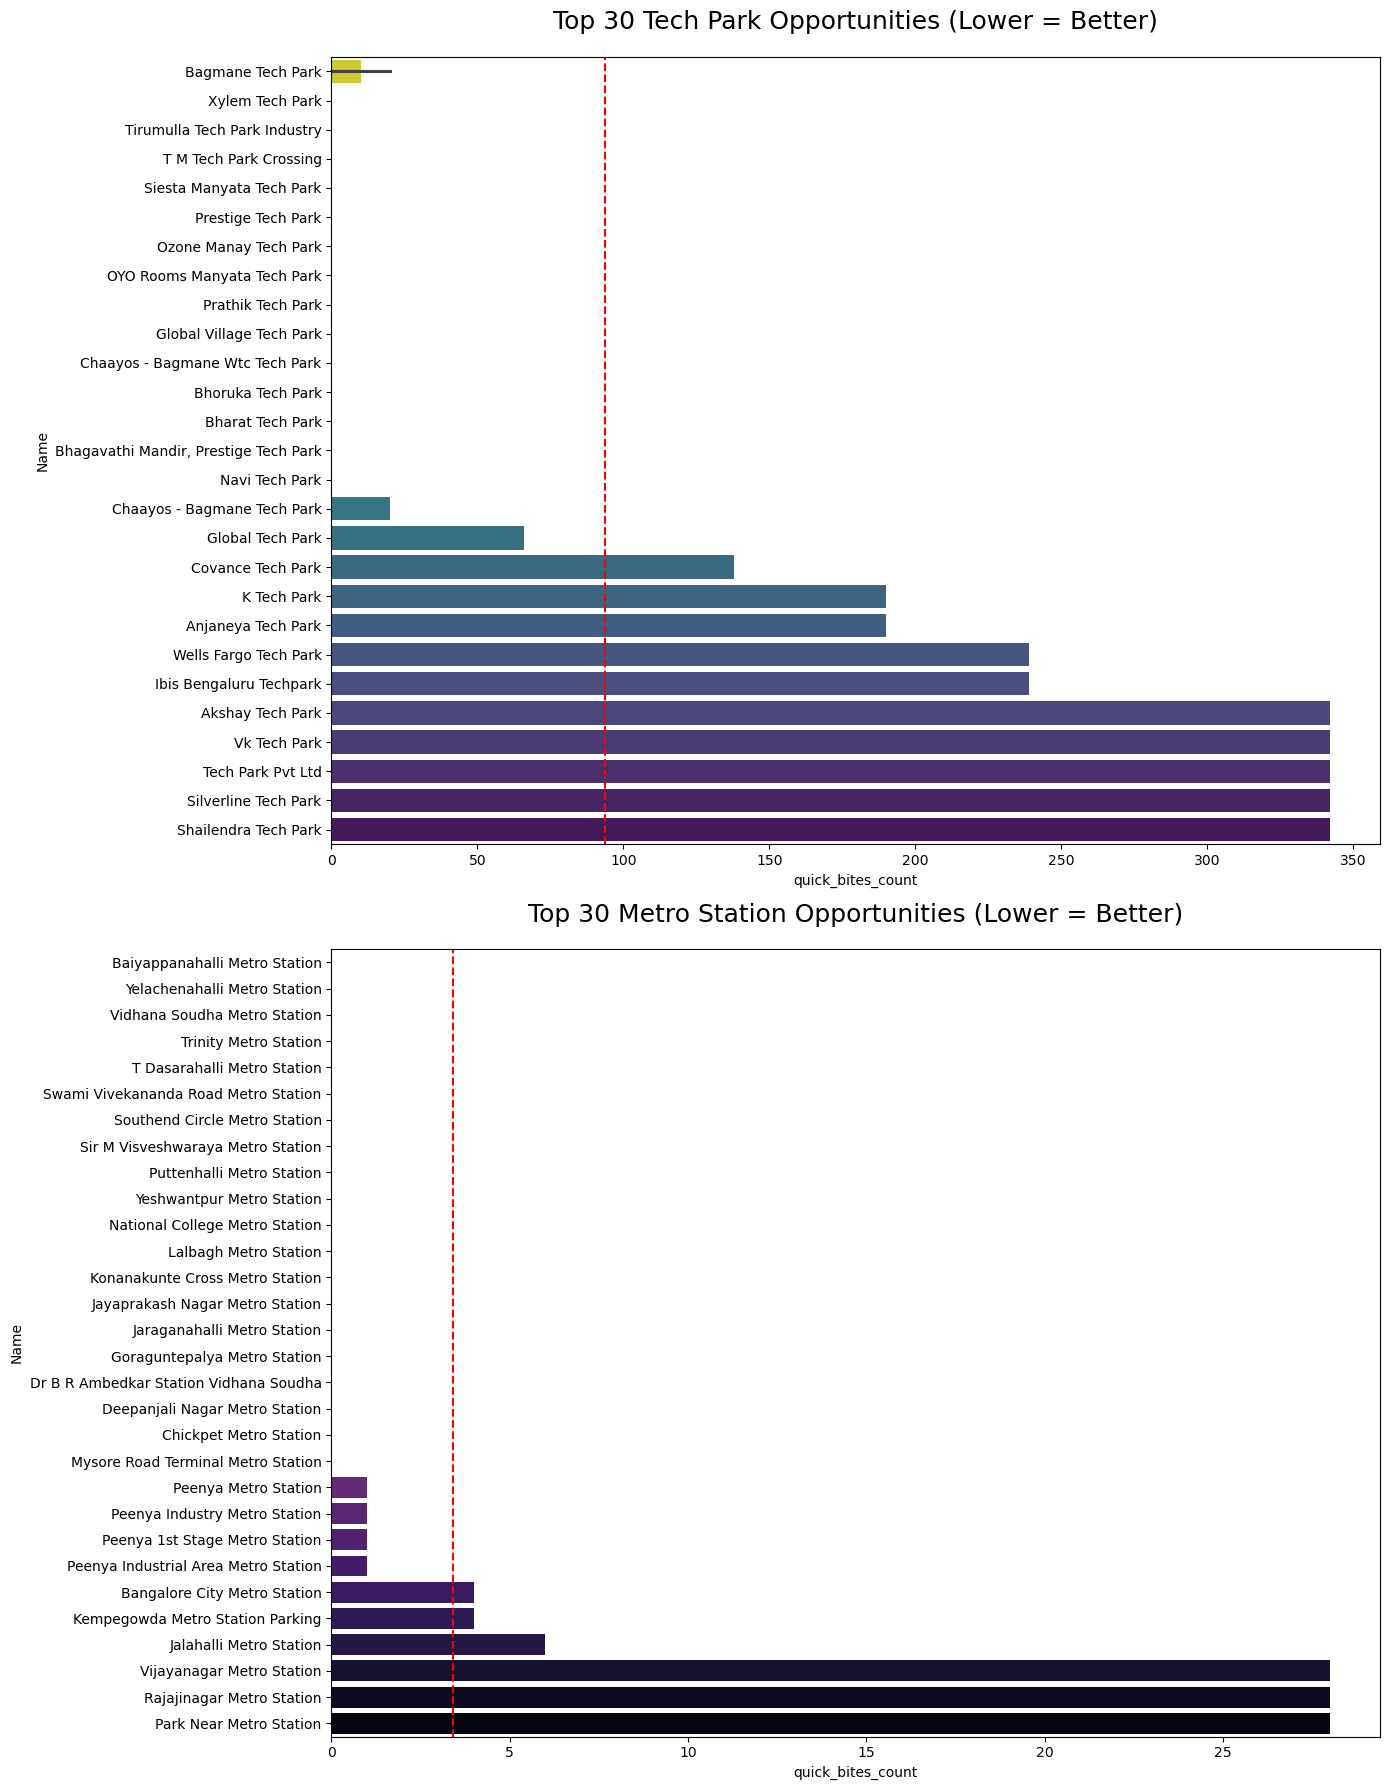

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt


top_30_tech = final_tech_report.sort_values('quick_bites_count').head(30)
top_30_metro = final_metro_report.sort_values('quick_bites_count').head(30)

# Set up a larger figure for 30 items
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 18))

# Plot 1: Tech Park Analysis
sns.barplot(
    data=top_30_tech, 
    x='quick_bites_count', 
    y='Name', 
    hue='Name',
    legend=False,
    palette='viridis_r', 
    ax=ax1
)
ax1.set_title('Top 30 Tech Park Opportunities (Lower = Better)', fontsize=18, pad=20)
ax1.axvline(top_30_tech['quick_bites_count'].mean(), color='red', linestyle='--', label='Avg Competition')

# Plot 2: Metro Station Analysis
sns.barplot(
    data=top_30_metro, 
    x='quick_bites_count', 
    y='Name', 
    hue='Name',
    legend=False,
    palette='magma_r', 
    ax=ax2
)
ax2.set_title('Top 30 Metro Station Opportunities (Lower = Better)', fontsize=18, pad=20)
ax2.axvline(top_30_metro['quick_bites_count'].mean(), color='red', linestyle='--', label='Avg Competition')

plt.tight_layout()
plt.show()

#### Analysis of the "Top 30" Results
**The "Zero-Competition" Leaders**: The top 5–10 rows in both charts represent areas where TomTom identified high-traffic hubs but Zomato reported zero "Quick Bite" competition. These are our primary targets.

**The "Red Line" Benchmark**: The red dashed line shows the average competition density across Bangalore. Any location to the left of this line is an "Underserved Market."



## Food Truck Location Recommendation

Based on the restaurant dataset alone, Basavanagudi emerges as the strongest preliminary candidate, while Majestic appears promising but requires further validation due to possible score inflation caused by low competition.
Our pilot launch should target the top-ranked Tech Park during lunch hours and the top-ranked Metro Station during morning/evening transit peaks. This "Dual-Location" strategy maximizes daily revenue by following the crowd.